<a href="https://colab.research.google.com/github/zain4cs/E-Com_data/blob/main/E_Com_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/Pakistan Largest Ecommerce Dataset.csv")
df.head()

/tmp/ipykernel_9523/4226985986.py:1: DtypeWarning: Columns (1,2,3,7,8,9,11,12,13,14,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/Datasets/Pakistan Largest Ecommerce Dataset.csv")


,item_id,status,created_at,sku,price,qty_ordered,grand_total,increment_id,category_name_1,sales_commission_code,...,Month,Customer Since,M-Y,FY,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131.0,complete,7/1/2016,kreations_YI 06-L,1950.0,1.0,1950.0,100147443,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,1.0,NaN,NaN,NaN,NaN,NaN
1,211133.0,canceled,7/1/2016,kcc_Buy 2 Frey Air Freshener & Get 1 Kasual Bo...,240.0,1.0,240.0,100147444,Beauty & Grooming,\N,...,7.0,2016-7,7-2016,FY17,2.0,NaN,NaN,NaN,NaN,NaN
2,211134.0,canceled,7/1/2016,Ego_UP0017-999-MR0,2450.0,1.0,2450.0,100147445,Women's Fashion,\N,...,7.0,2016-7,7-2016,FY17,3.0,NaN,NaN,NaN,NaN,NaN
3,211135.0,complete,7/1/2016,kcc_krone deal,360.0,1.0,60.0,100147446,Beauty & Grooming,R-FSD-52352,...,7.0,2016-7,7-2016,FY17,4.0,NaN,NaN,NaN,NaN,NaN
4,211136.0,order_refunded,7/1/2016,BK7010400AG,555.0,2.0,1110.0,100147447,Soghaat,\N,...,7.0,2016-7,7-2016,FY17,5.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.shape

(1048575, 26)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   item_id                584524 non-null  float64
 1   status                 584509 non-null  object 
 2   created_at             584524 non-null  object 
 3   sku                    584504 non-null  object 
 4   price                  584524 non-null  float64
 5   qty_ordered            584524 non-null  float64
 6   grand_total            584524 non-null  float64
 7   increment_id           584524 non-null  object 
 8   category_name_1        584360 non-null  object 
 9   sales_commission_code  447346 non-null  object 
 10  discount_amount        584524 non-null  float64
 11  payment_method         584524 non-null  object 
 12  Working Date           584524 non-null  object 
 13  BI Status              584524 non-null  object 
 14   MV                    584524 non-

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Unnamed: 23,1048575
Unnamed: 22,1048575
Unnamed: 25,1048575
Unnamed: 24,1048575
Unnamed: 21,1048575
sales_commission_code,601229
category_name_1,464215
sku,464071
status,464066
Customer Since,464062


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df.columns

Index(['item_id', 'status', 'created_at', 'sku', 'price', 'qty_ordered',
       'grand_total', 'increment_id', 'category_name_1',
       'sales_commission_code', 'discount_amount', 'payment_method',
       'Working Date', 'BI Status', 'MV', 'Year', 'Month', 'Customer Since',
       'M-Y', 'FY', 'Customer ID', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23',
       'Unnamed: 24', 'Unnamed: 25'],
      dtype='object')

In [ ]:
num_columns = df.select_dtypes(include=['int', 'float'])
num_columns.head()

,item_id,price,qty_ordered,grand_total,discount_amount,Year,Month,Customer ID,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,211131.0,1950.0,1.0,1950.0,0.0,2016.0,7.0,1.0,NaN,NaN,NaN,NaN,NaN
1,211133.0,240.0,1.0,240.0,0.0,2016.0,7.0,2.0,NaN,NaN,NaN,NaN,NaN
2,211134.0,2450.0,1.0,2450.0,0.0,2016.0,7.0,3.0,NaN,NaN,NaN,NaN,NaN
3,211135.0,360.0,1.0,60.0,300.0,2016.0,7.0,4.0,NaN,NaN,NaN,NaN,NaN
4,211136.0,555.0,2.0,1110.0,0.0,2016.0,7.0,5.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
corr = num_columns.corr()['grand_total'].sort_values(ascending=False)
corr

,grand_total
grand_total,1.000000
qty_ordered,0.753487
price,0.277607
discount_amount,0.104825
Customer ID,0.054043
item_id,0.049265
Year,0.048432
Month,-0.020887
Unnamed: 21,NaN
Unnamed: 22,NaN


**Data Cleaning**

In [ ]:
essential = ['created_at', 'grand_total', 'qty_ordered',
             'price', 'discount_amount', 'category_name_1', 'payment_method']

In [ ]:
df = df[essential].copy()

In [ ]:
df = df.dropna(subset=['grand_total', 'price', 'qty_ordered'])

In [ ]:
df = df[(df['price']>0) & (df['grand_total']>0) & (df['qty_ordered']>0)]

In [ ]:
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

In [ ]:
df['created_at'].info()

<class 'pandas.core.series.Series'>
Index: 572750 entries, 0 to 584523
Series name: created_at
Non-Null Count   Dtype         
--------------   -----         
572750 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 8.7 MB


In [ ]:
df['order_month'] = df['created_at'].dt.to_period('M').astype('str')

In [ ]:
print("Clean Data", df.shape)

Clean Data (572750, 8)


In [ ]:
df.head()

,created_at,grand_total,qty_ordered,price,discount_amount,category_name_1,payment_method,order_month
0,2016-07-01,1950.0,1.0,1950.0,0.0,Women's Fashion,cod,2016-07
1,2016-07-01,240.0,1.0,240.0,0.0,Beauty & Grooming,cod,2016-07
2,2016-07-01,2450.0,1.0,2450.0,0.0,Women's Fashion,cod,2016-07
3,2016-07-01,60.0,1.0,360.0,300.0,Beauty & Grooming,cod,2016-07
4,2016-07-01,1110.0,2.0,555.0,0.0,Soghaat,cod,2016-07


**Graph and EDA**

In [ ]:
df.isnull().sum()

,0
created_at,0
grand_total,0
qty_ordered,0
price,0
discount_amount,0
category_name_1,163
payment_method,0
order_month,0


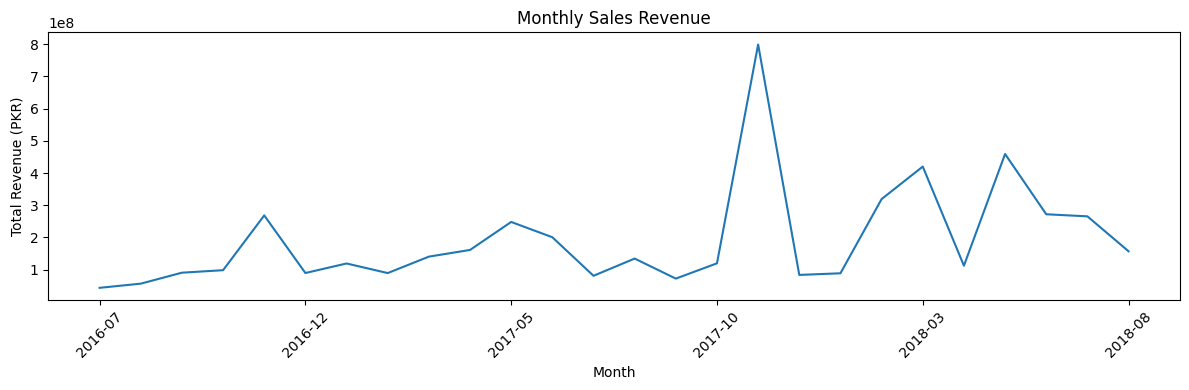

In [ ]:
plt.figure(figsize=(12,4))
monthly = df.groupby('order_month')['grand_total'].sum()
monthly.plot()
plt.title("Monthly Sales Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue (PKR)")
plt.xticks(rotation=45)
plt.tight_layout()

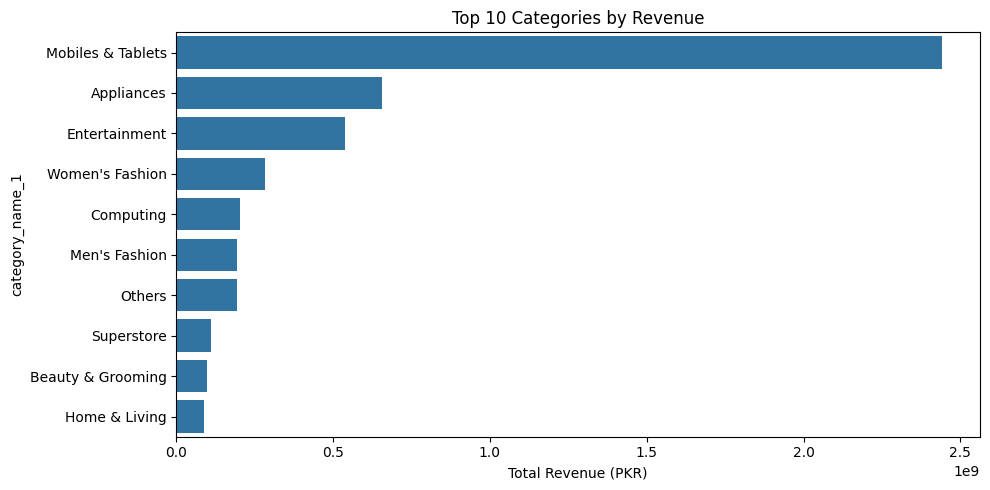

In [ ]:
plt.figure(figsize=(10,5))
top_cat = df.groupby('category_name_1')['grand_total'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_cat.values, y=top_cat.index)
plt.title("Top 10 Categories by Revenue")
plt.xlabel("Total Revenue (PKR)")
plt.tight_layout()

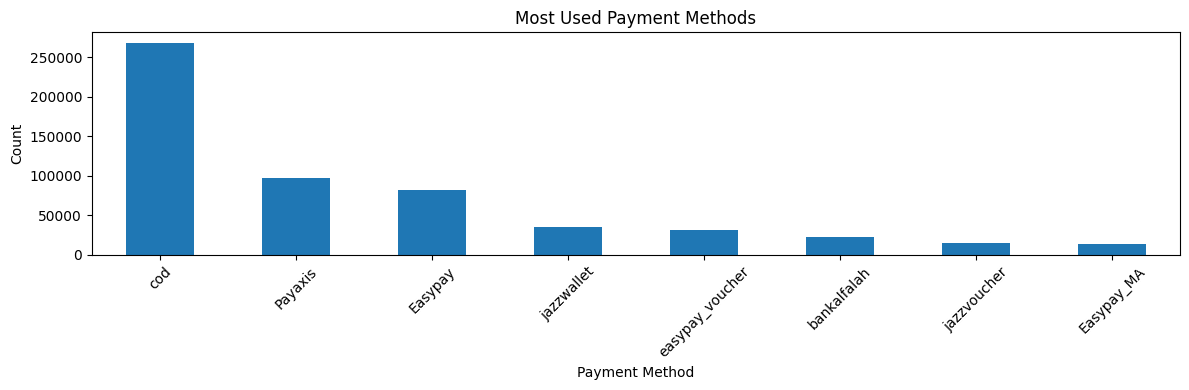

In [ ]:
plt.figure(figsize=(12,4))
df['payment_method'].value_counts().head(8).plot(kind='bar')
plt.title("Most Used Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()

**Feature Engineering**

In [ ]:
df['category_name_1'] = df['category_name_1'].fillna('Unknown')

In [ ]:
df['category_encoded'] = pd.factorize(df['category_name_1'])[0]

In [ ]:
print(df[['category_name_1', 'category_encoded']].drop_duplicates().head())

      category_name_1  category_encoded
0     Women's Fashion                 0
1   Beauty & Grooming                 1
4             Soghaat                 2
8   Mobiles & Tablets                 3
10         Appliances                 4


**Model**

In [ ]:
X = df[['price', 'qty_ordered', 'discount_amount', 'category_encoded']]
y = df['grand_total']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 458200
Testing rows: 114550


In [ ]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

In [ ]:
print("R² Score:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

R² Score: 0.9732579582876143
MAE: 2096.1829487266436


**Feature Importance**

In [ ]:
feature_names = ['price', 'qty_ordered', 'discount_amount', 'category_encoded']
importances = model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

feat_df


,Feature,Importance
1,qty_ordered,0.895270
0,price,0.096956
2,discount_amount,0.005493
3,category_encoded,0.002281
